# Primer parcial – Sistemas Inteligentes II

**Estudiante:** Daniela Agudelo Martínez  
**Curso:** Sistemas Inteligentes II  
**Profesor:** Jorge Alberto Jaramillo Garzón

Este notebook contiene el desarrollo completo de los ejercicios del primer parcial sobre la base de datos Iris:

1. Implementación de validación cruzada k-fold sin librerías de validación y comparación entre:
   - Clasificador Naive Bayes con distribución gaussiana.
   - Clasificador geométrico por mínimos cuadrados con regularización ridge (λ).
2. Implementación de K-NN y análisis de desempeño mediante bootstrapping para distintos valores de \(k\).
3. Discusión teórica comparando los tres clasificadores: geométrico, bayesiano y K-NN.
4. Sustentación práctica: barrido del parámetro \(\lambda\) en Ridge y análisis de accuracy y estabilidad entre folds.


In [13]:
import sys
print(sys.executable)

# Instalar scikit-learn en el mismo Python que usa este notebook
!{sys.executable} -m pip install scikit-learn

C:\Users\USUARIO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\USUARIO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [14]:
# Imports

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix


plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 10

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [15]:
# Carga y preparación del dataset Iris

iris = load_iris()
x_full = iris.data          # 4 características
y_full = iris.target        # 0=setosa, 1=versicolor, 2=virginica
class_names_full = iris.target_names

print("Clases originales:", class_names_full)
print("Forma de x_full:", x_full.shape)

# Para el ejercicio 1: solo clases versicolor (1) y virginica (2)
mask_ex1 = (y_full == 1) | (y_full == 2)
x_ex1 = x_full[mask_ex1] # elimino las filas que no son versicolor o virginica
y_ex1 = y_full[mask_ex1] 

print("\nEjercicio 1:")
print("  X_ex1 shape:", x_ex1.shape)
print("  y_ex1 shape:", y_ex1.shape)
print("  y_ex1 clases:", np.unique(y_ex1))

# Para el ejercicio 2 usaremos X_full, y_full (las 3 clases)

Clases originales: ['setosa' 'versicolor' 'virginica']
Forma de x_full: (150, 4)

Ejercicio 1:
  X_ex1 shape: (100, 4)
  y_ex1 shape: (100,)
  y_ex1 clases: [1 2]


**Utilidades:**

- **Estandarización:** Estandarizamos ya que las escalas de las características pueden dominar. En cada fold calculo la media $\boldsymbol{\mu}$ y la desviación estándar $\boldsymbol{\sigma}$ solo con el conjunto de entrenamiento; luego aplico $x'_j = (x_j - \mu_j) / \sigma_j$ a train 
y a test.
- **Accuracy:** Proporción de aciertos:
$$ \text{accuracy} = \frac{1}{n} \sum_{i=1}^n \mathbb{1}(\hat{y}_i = y_i) $$
- **Matriz de confusión:** Tabla donde la fila $i$ es la clase real y la columna $j$ la predicha; el elemento $(i,j)$ es el número de muestras con clase real $i$ y predicha $j$.

In [16]:
# Utilidades: estandarización y métricas básicas

from typing import Tuple


def standardize_fit(X: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Calcula media y desviación estándar por característica y devuelve X estandarizada.
    """
    mean = X.mean(axis=0) 
    std = X.std(axis=0)
    std[std == 0] = 1.0
    X_std = (X - mean) / std
    return X_std, mean, std


def standardize_apply(X: np.ndarray, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    """Aplica la estandarización (media y desviación) calculada en entrenamiento."""
    return (X - mean) / std


def accuracy_score_numpy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return np.mean(y_true == y_pred)


def confusion_matrix_numpy(y_true: np.ndarray, y_pred: np.ndarray, labels=None) -> np.ndarray:
    """Matriz de confusión usando sklearn.metrics.confusion_matrix"""
    if labels is None:
        labels = np.unique(np.concatenate([y_true, y_pred]))
    labels = np.array(labels)
    matriz_confusion = confusion_matrix(y_true, y_pred, labels=labels)
    return matriz_confusion, labels

## Ejercicio 1 – Naive Bayes Gaussiano y Mínimos Cuadrados Ridge con k-fold

En este ejercicio implemento:

- Un clasificador Naive Bayes Gaussiano.
- Un clasificador geométrico basado en mínimos cuadrados con regularización ridge (λ).
- El procedimiento de validación cruzada k-fold.

En cada fold:

- Estandarizo las características usando solo el conjunto de entrenamiento.
- Entreno el modelo sobre el conjunto de entrenamiento estandarizado.
- Evalúo sobre el conjunto de prueba estandarizado y guardo:
  - Accuracy por fold.
  - Matriz de confusión por fold.

Al final, se muestra el accuracy promedio, la varianza de la accuracy entre folds y la matriz de confusión promedio para cada modelo y cada valor de \(k\).

---------------------------------------------------------------------------------------------------


**1. Naive Bayes Gaussiano (clasificador generativo)**  
Usamos el teorema de Bayes para la clase $c_i$ dado el vector de características $\boldsymbol{x}$:
$$ p(c_i \mid \boldsymbol{x}) = \frac{p(\boldsymbol{x} \mid c_i) \, p(c_i)}{p(\boldsymbol{x})} $$
El denominador $p(\boldsymbol{x})$ es igual para todas las clases, así que para clasificar solo necesitamos el numerador. Modelamos la verosimilitud $p(\boldsymbol{x} \mid c_i)$ con una densidad gaussiana (por clase y por característica, asumiendo independencia “naive”):
$$ p(\boldsymbol{x} \mid c_i) \propto \prod_{j} \frac{1}{\sqrt{2\pi\sigma_{i,j}^2}} \exp\left(-\frac{(x_j - \mu_{i,j})^2}{2\sigma_{i,j}^2}\right) $$
En entrenamiento calculamos para cada clase: prior $p(c_i)$ (proporción de muestras), medias $\mu_{i,j}$ y varianzas $\sigma_{i,j}^2$. En predicción trabajamos en log-verosimilitud para evitar underflow y elegimos la clase con mayor score.

**2. Mínimos cuadrados con regularización Ridge (clasificador geométrico)**  
Buscamos una frontera de decisión lineal $\boldsymbol{w}^T \boldsymbol{x} = 0$. Las etiquetas las mapeamos a $-1$ y $+1$. Añadimos un término de bias (columna de unos) en $\boldsymbol{X}$. Minimizamos el error cuadrático con regularización $\lambda$:
$$ \boldsymbol{w} = \left( \boldsymbol{X}^T \boldsymbol{X} + \lambda \boldsymbol{I} \right)^{-1} \boldsymbol{X}^T \boldsymbol{y} $$
Predecimos con el signo de $\boldsymbol{w}^T \boldsymbol{x}$: si es positivo asignamos una clase, si es negativo la otra.

¿Qué entendemos por regularización ridge en mínimos cuadrados?  
En el clasificador geométrico estamos resolviendo un problema de mínimos cuadrados, pero añadimos un término de regularización Ridge. Sin regularización, buscaríamos $\boldsymbol{w}$ que minimiza el error cuadrático $\sum_i (y_i - \boldsymbol{w}^T \boldsymbol{x}_i)^2$. Con Ridge, lo que hacemos es minimizar una combinación de error de ajuste y tamaño de los pesos:
$$ \min_{\boldsymbol{w}} \; \sum_i (y_i - \boldsymbol{w}^T \boldsymbol{x}_i)^2 \, + \, \lambda \lVert \boldsymbol{w} \rVert_2^2, $$
lo que lleva a la solución cerrada
$$ \boldsymbol{w} = \left( \boldsymbol{X}^T \boldsymbol{X} + \lambda \boldsymbol{I} \right)^{-1} \boldsymbol{X}^T \boldsymbol{y}. $$
Al sumar $\lambda \boldsymbol{I}$ estamos penalizando pesos muy grandes y suavizando la frontera de decisión.

¿Para qué nos sirve y qué pasa si cambiamos $\lambda$? 
Usamos ridge porque queremos que el modelo generalice bien y sea numéricamente estable. Si $\lambda$ es muy pequeño (cercano a 0), el modelo se parece a mínimos cuadrados “puros”: puede ajustar muy bien el conjunto de entrenamiento pero corre más riesgo de sobreajuste. Si $\lambda$ es intermedio (por ejemplo, $\lambda = 1.0$), obtenemos un compromiso razonable: permitimos que el modelo se adapte a los datos, pero evitamos pesos excesivos y ganamos estabilidad. Si $\lambda$ fuera muy grande, forzaríamos a $\boldsymbol{w}$ a ser casi cero, la frontera se volvería demasiado simple y caeríamos en subajuste (el modelo ya no capturaría bien la separación entre versicolor y virginica).

In [17]:
class GaussianNaiveBayes:
    """Clasificador Naive Bayes con distribución gaussiana por característica y clase.
    """

    def __init__(self):
        self.classes_ = None
        self.class_priors_ = None  # p(Y=c)
        self.means_ = None         # matriz de medias
        self.vars_ = None          # matriz de varianzas

    def fit(self, X: np.ndarray, y: np.ndarray):
        X = np.asarray(X)
        y = np.asarray(y)
        n_samples, n_features = X.shape

        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)

        self.means_ = np.zeros((n_classes, n_features))
        self.vars_ = np.zeros((n_classes, n_features))
        self.class_priors_ = np.zeros(n_classes)

        for idx, c in enumerate(self.classes_):
            X_c = X[y == c] # extraigo las filas que tienen la clase c
            self.means_[idx, :] = X_c.mean(axis=0) # calculo la media de las características para la clase c
            self.vars_[idx, :] = X_c.var(axis=0) + 1e-9 # evito que haya varianzas cero
            self.class_priors_[idx] = X_c.shape[0] / n_samples 

    def _log_gaussian(self, class_idx: int, X: np.ndarray) -> np.ndarray:
        """Devuelve log p(X | clase=class_idx) para cada muestra."""
        mean = self.means_[class_idx]
        var = self.vars_[class_idx]
        # Fórmula de log de la gaussiana multivariada con independencia entre característocas
        log_prob = -0.5 * np.sum(np.log(2.0 * np.pi * var))
        log_prob -= 0.5 * np.sum(((X - mean) ** 2) / var, axis=1)
        return log_prob

    def predict(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X)
        n_samples = X.shape[0]
        n_classes = len(self.classes_)

        log_posteriors = np.zeros((n_samples, n_classes))

        for idx, c in enumerate(self.classes_):
            # log p(Y=c) + log p(X|Y=c)
            log_prior = np.log(self.class_priors_[idx])
            log_likelihood = self._log_gaussian(idx, X)
            log_posteriors[:, idx] = log_prior + log_likelihood

        # Elegir la clase con mayor log-posterior
        indices = np.argmax(log_posteriors, axis=1)
        return self.classes_[indices]


class RidgeLeastSquaresClassifier:
    """Clasificador geométrico por mínimos cuadrados con regularización ridge.

    Asumimos dos clases (binario). Codifico las clases como -1 y +1, ajusto un
    modelo lineal y clasifico según el signo de w^T x.
    """

    def __init__(self, lam: float = 1.0):
        self.lam = lam
        self.w_ = None       # pesos incluyendo bias
        self.classes_ = None # valores originales de las dos clases

    def fit(self, X: np.ndarray, y: np.ndarray):
        X = np.asarray(X)
        y = np.asarray(y)
        n_samples, n_features = X.shape

        self.classes_ = np.unique(y)
        if len(self.classes_) != 2:
            raise ValueError("RidgeLeastSquaresClassifier solo implementado para problemas binarios")

        # Mapear las clases originales a -1 y +1
        y_mapped = np.where(y == self.classes_[1], 1.0, -1.0)

        # Añadir columna de unos para el bias
        X_bias = np.hstack([X, np.ones((n_samples, 1))])  

        # Resolver (X^T X + λI) w = X^T y
        d_plus_1 = X_bias.shape[1]
        A = X_bias.T @ X_bias + self.lam * np.eye(d_plus_1)
        b = X_bias.T @ y_mapped
        self.w_ = np.linalg.solve(A, b)
        
        '''En estas líneas estoy resolviendo analíticamente el problema de Ridge Regression. 
        Primero defino la dimensión del espacio incluyendo el bias, luego construyo la matriz de 
        covarianzas penalizada por el factor lambda para controlar el overfitting, y finalmente 
        calculo el vector de términos independientes para resolver el sistema Aw = b mediante el
        método de mínimos cuadrados'''

    def predict(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X)
        n_samples = X.shape[0]
        X_bias = np.hstack([X, np.ones((n_samples, 1))])
        scores = X_bias @ self.w_
        y_mapped_pred = np.where(scores >= 0.0, 1.0, -1.0)
        # Volver a las etiquetas originales
        y_pred = np.where(y_mapped_pred == 1.0, self.classes_[1], self.classes_[0])
        return y_pred

Qué hacemos en la validación cruzada k-fold: Dividimos los datos en $k$ particiones (folds) de tamaño similar. En cada iteración usamos $k-1$ folds para entrenar y 1 fold para prueba; así repetimos $k$ veces y cada muestra queda exactamente una vez en prueba. En cada fold: (1) calculamos media y desviación de las características solo con el train; (2) estandarizamos train y test con esos valores; (3) entrenamos el modelo con el train estandarizado; (4) predecimos en el test estandarizado y calculamos accuracy y matriz de confusión. Al final se reporta el accuracy promedio, la varianza de la accuracy entre folds y la matriz de confusión promedio para cada modelo y cada $k$ (2, 5, 10).

In [18]:
# Implementación de validación cruzada k-fold
def k_fold_indices(n_samples: int, k: int, random_state: int = 42):
    """Genera índices de entrenamiento y prueba para k-fold."""
    rng = np.random.RandomState(random_state)
    indices = np.arange(n_samples)
    rng.shuffle(indices)

    fold_sizes = np.full(k, n_samples // k, dtype=int)
    fold_sizes[: n_samples % k] += 1

    current = 0
    folds = []
    for fold_size in fold_sizes:
        start, stop = current, current + fold_size
        folds.append(indices[start:stop])
        current = stop

    # Para cada fold, generamos (train_idx, test_idx)
    splits = []
    for i in range(k):
        test_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        splits.append((train_idx, test_idx))
    return splits


def cross_validate_model(X: np.ndarray,
                         y: np.ndarray,
                         model_class,
                         k: int,
                         standardize: bool = True,
                         random_state: int = 42,
                         verbose: bool = True,
                         **model_kwargs):
    """Realiza validación cruzada k-fold para un modelo dado.

    - X, y: datos completos.
    - model_class: clase del modelo (por ejemplo GaussianNaiveBayes).
    - k: número de folds.
    - standardize: si True, estandariza usando SOLO el conjunto de entrenamiento de cada fold.
    - verbose: si True, imprime la accuracy de cada fold.
    - model_kwargs: parámetros a pasar al constructor del modelo.

    Devuelve un diccionario con accuracies por fold, varianza, y matriz de confusión promedio.
    """
    X = np.asarray(X)
    y = np.asarray(y)
    n_samples = X.shape[0]

    splits = k_fold_indices(n_samples, k, random_state=random_state)

    accuracies = []
    conf_matrices = []
    labels_global = np.unique(y)

    for fold_idx, (train_idx, test_idx) in enumerate(splits):
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]

        if standardize:
            X_train_std, mean, std = standardize_fit(X_train)
            X_test_std = standardize_apply(X_test, mean, std)
        else:
            X_train_std, X_test_std = X_train, X_test

        model = model_class(**model_kwargs)
        model.fit(X_train_std, y_train)
        y_pred = model.predict(X_test_std)

        acc = accuracy_score_numpy(y_test, y_pred)
        cm, _ = confusion_matrix_numpy(y_test, y_pred, labels=labels_global)

        accuracies.append(acc)
        conf_matrices.append(cm)

        if verbose:
            print(f"Fold {fold_idx+1}/{k} - accuracy = {acc:.4f}")

    accuracies = np.array(accuracies)
    conf_matrices = np.array(conf_matrices)

    mean_acc = accuracies.mean()
    var_acc = accuracies.var(ddof=1) if len(accuracies) > 1 else 0.0
    mean_cm = conf_matrices.mean(axis=0)

    return {
        "accuracies": accuracies,
        "mean_accuracy": mean_acc,
        "var_accuracy": var_acc,
        "mean_confusion_matrix": mean_cm,
        "labels": labels_global,
    }

In [19]:
# Validación cruzada para Gaussian Naive Bayes y Ridge en Iris (versicolor vs virginica)

ks = [2, 5, 10]

results_nb = {}
results_ridge = {}

print("=== Validación cruzada en Iris (versicolor vs virginica) ===\n")

for k in ks:
    print(f"\n##### k = {k} folds \n")

    print("Naive Bayes Gaussiano:")
    res_nb = cross_validate_model(x_ex1, y_ex1, GaussianNaiveBayes, k=k, standardize=True, random_state=42)
    results_nb[k] = res_nb
    print(f"  -> Accuracy promedio: {res_nb['mean_accuracy']:.4f}")
    print(f"  -> Varianza accuracy: {res_nb['var_accuracy']:.6f}")
    print("  -> Matriz de confusión promedio (filas=clase real, columnas=predicha):")
    print(res_nb["mean_confusion_matrix"])

    print("\nMínimos cuadrados Ridge (λ=1.0):")
    res_ridge = cross_validate_model(x_ex1, y_ex1, RidgeLeastSquaresClassifier, k=k, standardize=True, random_state=42, lam=1.0)
    results_ridge[k] = res_ridge
    print(f"  -> Accuracy promedio: {res_ridge['mean_accuracy']:.4f}")
    print(f"  -> Varianza accuracy: {res_ridge['var_accuracy']:.6f}")
    print("  -> Matriz de confusión promedio (filas=clase real, columnas=predicha):")
    print(res_ridge["mean_confusion_matrix"])

=== Validación cruzada en Iris (versicolor vs virginica) ===


##### k = 2 folds 

Naive Bayes Gaussiano:
Fold 1/2 - accuracy = 0.9400
Fold 2/2 - accuracy = 0.9400
  -> Accuracy promedio: 0.9400
  -> Varianza accuracy: 0.000000
  -> Matriz de confusión promedio (filas=clase real, columnas=predicha):
[[23.5  1.5]
 [ 1.5 23.5]]

Mínimos cuadrados Ridge (λ=1.0):
Fold 1/2 - accuracy = 0.9600
Fold 2/2 - accuracy = 1.0000
  -> Accuracy promedio: 0.9800
  -> Varianza accuracy: 0.000800
  -> Matriz de confusión promedio (filas=clase real, columnas=predicha):
[[24.  1.]
 [ 0. 25.]]

##### k = 5 folds 

Naive Bayes Gaussiano:
Fold 1/5 - accuracy = 0.9500
Fold 2/5 - accuracy = 0.9500
Fold 3/5 - accuracy = 0.9500
Fold 4/5 - accuracy = 0.9500
Fold 5/5 - accuracy = 0.8500
  -> Accuracy promedio: 0.9300
  -> Varianza accuracy: 0.002000
  -> Matriz de confusión promedio (filas=clase real, columnas=predicha):
[[9.4 0.6]
 [0.8 9.2]]

Mínimos cuadrados Ridge (λ=1.0):
Fold 1/5 - accuracy = 0.8000
Fold 2/5

### Comentarios 

**Comparación de accuracy y matrices de confusión**  
En los tres valores de \(k\) el clasificador por mínimos cuadrados Ridge obtiene un accuracy promedio mayor que el Naive Bayes gaussiano. Por ejemplo, para \(k=2\) la accuracy promedio de Ridge es 0.98 frente a 0.94 de Naive Bayes, para \(k=5\) es 0.96 frente a 0.93 y para \(k=10\) es 0.97 frente a 0.93. Las matrices de confusión promedio de ambos modelos muestran que casi siempre aciertan en ambas clases, con muy pocos errores de confusión entre versicolor y virginica; es decir, los dos modelos son bastante buenos en este problema linealmente separable, pero Ridge aprovecha un poco mejor la separación geométrica.

**Varianza entre folds**  
En Naive Bayes la varianza de la accuracy es muy baja para \(k=2\) (0.0) y va aumentando ligeramente a 0.002 para \(k=5\) y 0.0046 para \(k=10\). En Ridge la varianza es 0.0008 para \(k=2\), sube a 0.008 en \(k=5\) y baja a 0.0023 en \(k=10\). Esto indica que cuando hacemos más particiones (especialmente con pocos datos por fold, como en \(k=5\)) las estimaciones pueden ser un poco más inestables, sobre todo para Ridge, que depende más de la geometría exacta de los puntos en cada fold.

**Balance entre varianza y costo computacional**  
El costo computacional de la validación cruzada crece linealmente con \(k\), porque hay que entrenar el modelo \(k\) veces. En mi caso, pasar de \(k=2\) a \(k=10\) significa multiplicar por cinco el número de entrenamientos. A cambio de ese costo extra, se obtiene una estimación del desempeño más robusta que usar solo una partición simple, pero los resultados muestran que, en este dataset pequeño y relativamente fácil, las diferencias de accuracy promedio entre \(k=2,5,10\) son pequeñas. Para este problema concreto, un valor intermedio como \(k=5\) ya ofrece un compromiso razonable entre costo computacional y estabilidad de la estimación.

## Ejercicio 2 – Clasificador K-NN y bootstrapping en Iris (3 clases)

Ahora implemento un clasificador **K-NN** y analizo su desempeño con la base Iris completa (3 clases), usando el método de **bootstrapping** a medida que incremento el número de vecinos \(k\).

La idea es:

1. Implementar K-NN usando distancia euclídea.
2. Implementar un procedimiento de bootstrapping:
   - En cada iteración, tomar una muestra bootstrap con reemplazo.
   - Entrenar K-NN en esa muestra.
   - Evaluar en las muestras "out-of-bag" (no seleccionadas).
3. Repetir el proceso muchas veces para distintos valores de \(k\) y graficar:
   - Accuracy promedio vs \(k\).
   - barras de desviación estándar.
4. Concluir qué valores de \(k\) producen **sobreajuste** y **subajuste**, justificando con las gráficas.

**Fórmula que usamos en K-NN:** Medimos la similitud con la **distancia euclidiana** (norma 2):
$$ \|\boldsymbol{x} - \boldsymbol{y}\|_2 = \sqrt{\sum_{j} (x_j - y_j)^2} $$
Para cada punto nuevo, calculamos su distancia a todas las muestras de entrenamiento, elegimos los **k vecinos más cercanos** y asignamos la clase por **voto mayoritario** (la clase que más veces aparece entre esos k). No hay una fase de “entrenamiento” con parámetros: solo guardamos el conjunto de entrenamiento y en predicción repetimos este proceso. Con **bootstrapping** repetimos muchas veces: en cada iteración tomamos una muestra con reemplazo, “entreno” K-NN en esa muestra y evaluamos en las muestras out-of-bag para estimar la accuracy y su variabilidad según $k$.

In [20]:
class KNNClassifier:
    """Clasificador K-NN usando distancia euclídea y voto mayoritario.
    """

    def __init__(self, k: int = 5):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X: np.ndarray, y: np.ndarray):
        self.X_train = np.asarray(X)
        self.y_train = np.asarray(y)

    def _predict_one(self, x: np.ndarray):
        # Distancias euclídeas a todos los puntos de entrenamiento
        diffs = self.X_train - x
        dists = np.sqrt(np.sum(diffs ** 2, axis=1))
        # Índices de los k vecinos más cercanos
        nn_idx = np.argsort(dists)[: self.k] # Ordeno y me quedo con los primeros k
        nn_labels = self.y_train[nn_idx]
        # Voto mayoritario
        values, counts = np.unique(nn_labels, return_counts=True)
        return values[np.argmax(counts)]

    def predict(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X)
        preds = np.array([self._predict_one(x) for x in X])
        return preds


def bootstrap_knn_accuracies(X: np.ndarray,
                             y: np.ndarray,
                             k: int,
                             n_iterations: int = 200,
                             random_state: int = 42):
    """Ejecuta bootstrapping para un K-NN con k fijo.

    En cada iteración:
    - Muestra bootstrap con reemplazo.
    - Entrena K-NN en la muestra bootstrap.
    - Evalúa en datos out-of-bag (OOB).
    - Guarda la accuracy OOB.
    """
    X = np.asarray(X)
    y = np.asarray(y)
    n_samples = X.shape[0] # El número de muestras es el tamaño del dataset, pero habrá reemplazo

    rng = np.random.RandomState(random_state)
    accuracies = []

    for it in range(n_iterations):
        # 1. Crea la muestra bootstrap
        bootstrap_idx = rng.randint(0, n_samples, size=n_samples)
        # 2. Identifica los datos OOB
        oob_mask = np.ones(n_samples, dtype=bool)
        oob_mask[bootstrap_idx] = False 
        oob_idx = np.where(oob_mask)[0]

        # Puede ocurrir que no haya OOB
        if oob_idx.size == 0:
            continue

        X_boot, y_boot = X[bootstrap_idx], y[bootstrap_idx]
        X_oob, y_oob = X[oob_idx], y[oob_idx]
        
        # 3. Entrena y evalúa
        model = KNNClassifier(k=k)
        model.fit(X_boot, y_boot)
        y_pred_oob = model.predict(X_oob)

        acc = accuracy_score_numpy(y_oob, y_pred_oob)
        accuracies.append(acc)

    return np.array(accuracies)

In [21]:
# Ejecutar bootstrapping para distintos valores de k en K-NN (Iris completo)

k_values = list(range(1, 31))  # por ejemplo, de 1 a 30 vecinos
n_iterations = 1000

mean_accuracies = []
std_accuracies = []

print(f"Bootstrapping con {n_iterations} iteraciones por valor de k\n")

for k in k_values:
    accs = bootstrap_knn_accuracies(x_full, y_full, k=k, n_iterations=n_iterations, random_state=42)
    # Promedio de las n iteraciones del bootstrapping
    mean_accuracies.append(accs.mean())
    # Desviación estándar para saber qué tanto variaron 
    std_accuracies.append(accs.std())
    print(f"k = {k:2d} -> accuracy media = {accs.mean():.4f}, desvío = {accs.std():.4f}, iteraciones válidas = {len(accs)}")

mean_accuracies = np.array(mean_accuracies)
std_accuracies = np.array(std_accuracies)

# Gráfica de accuracy promedio vs k
plt.figure()
plt.errorbar(k_values, mean_accuracies, yerr=std_accuracies, fmt="-o", capsize=3)
plt.xlabel("Número de vecinos k")
plt.ylabel("Accuracy promedio (OOB)")
plt.title("Desempeño de K-NN en Iris con bootstrapping")
plt.grid(True)
plt.show()

Bootstrapping con 1000 iteraciones por valor de k

k =  1 -> accuracy media = 0.9554, desvío = 0.0220, iteraciones válidas = 1000
k =  2 -> accuracy media = 0.9478, desvío = 0.0253, iteraciones válidas = 1000
k =  3 -> accuracy media = 0.9539, desvío = 0.0239, iteraciones válidas = 1000
k =  4 -> accuracy media = 0.9498, desvío = 0.0265, iteraciones válidas = 1000
k =  5 -> accuracy media = 0.9552, desvío = 0.0253, iteraciones válidas = 1000
k =  6 -> accuracy media = 0.9525, desvío = 0.0275, iteraciones válidas = 1000
k =  7 -> accuracy media = 0.9573, desvío = 0.0256, iteraciones válidas = 1000
k =  8 -> accuracy media = 0.9561, desvío = 0.0266, iteraciones válidas = 1000
k =  9 -> accuracy media = 0.9585, desvío = 0.0250, iteraciones válidas = 1000
k = 10 -> accuracy media = 0.9574, desvío = 0.0259, iteraciones válidas = 1000
k = 11 -> accuracy media = 0.9597, desvío = 0.0245, iteraciones válidas = 1000
k = 12 -> accuracy media = 0.9579, desvío = 0.0258, iteraciones válidas = 1000
k

KeyboardInterrupt: 

### Comentarios 

**Forma general de la curva accuracy vs k**  
En todos los valores de $k$ el clasificador K-NN obtiene una accuracy media alta (entre ~0.945 y ~0.9597), lo que confirma que el dataset Iris es relativamente fácil de separar con este método. Con 1000 iteraciones de bootstrapping por valor de $k$, la estimación es más estable. Observamos que para valores intermedios de $k$ (aprox. entre 7 y 19) la accuracy media se mantiene alrededor de 0.956–0.960 (por ejemplo, 0.9573 para $k=7$, 0.9585 para $k=9$, 0.9597 para $k=11$, 0.9595 para $k=17$), mientras que para valores más grandes de $k$ (por encima de 22) la accuracy empieza a caer gradualmente hasta ~0.9451 en $k=30$.

**Sobreajuste (overfitting) y k pequeños**  
Teóricamente, los valores pequeños de $k$ (como $k=1,2,3$) hacen que el modelo sea muy flexible y muy sensible al ruido: basta un solo vecino atípico para cambiar la decisión. En nuestros resultados con 1000 iteraciones, $k=1$ tiene una accuracy media de 0.9554 y un desvío estándar de 0.0220; el rendimiento es bueno, pero el clasificador depende fuertemente de ejemplos individuales de la muestra bootstrap. Este comportamiento es típico de sobreajuste: el modelo se adapta mucho a detalles locales de los datos (cada punto “manda” mucho en su región), aunque en este dataset pequeño no se observa una caída clara del accuracy para $k$ pequeño.

**Subajuste (underfitting) y k grandes**  
A medida que aumentamos $k$ hacia valores muy grandes (por encima de 20), la frontera de decisión se vuelve cada vez más suave: al votar entre muchos vecinos, el clasificador tiende a promediar más y a ignorar detalles locales. En nuestros resultados, esto se ve en que la accuracy media empieza a bajar (por ejemplo, 0.9551 para $k=20$, 0.9485 para $k=26$, 0.9451 para $k=30$) y el desvío estándar aumenta (de ~0.026 en la zona intermedia a ~0.030–0.032 para $k \geq 22$). Este patrón es indicio de subajuste: el modelo se vuelve demasiado simple y pierde capacidad de discriminar bien entre clases cuando $k$ es demasiado grande.

**Qué hacemos en el bootstrapping y qué significa la desviación estándar**  
En cada valor de $k$ repetimos 1000 veces el siguiente experimento: (1) tomamos al azar, con reemplazo, un conjunto de entrenamiento a partir de Iris; (2) entrenamos K-NN con ese conjunto; (3) medimos la accuracy en los datos que quedaron por fuera (out-of-bag). Así obtenemos 1000 accuracies distintas para el mismo $k$. La **accuracy media** nos dice qué tan bien funciona K-NN con ese $k$ en promedio, y la **desviación estándar** nos dice qué tanto cambia esa accuracy cuando el conjunto de entrenamiento cambia un poco. Si la desviación estándar es pequeña, el modelo es estable frente a pequeñas variaciones en los datos; si es grande, su desempeño es muy sensible a qué ejemplos recibe en entrenamiento.

**Rango de k razonable para este problema**  
Entre $k \approx 5$ y $k \approx 19$ la accuracy media se mantiene alta (cerca de 0.955–0.959) y los desvíos estándar son moderados (~0.025–0.029). En este rango, K-NN ofrece un buen compromiso entre variabilidad y capacidad de generalización: no depende tanto de un solo vecino (como en $k=1$), pero tampoco promedia tanto como para perder la estructura de las clases (como en $k \geq 25$). En una aplicación real similar a Iris, elegiríamos un valor intermedio de $k$ dentro de este rango y lo justificaríamos con la forma de la curva obtenida por bootstrapping.

## Ejercicio 3 – Comparación teórica de los clasificadores

En esta sección respondo a las preguntas teóricas del ejercicio 3, apoyándome en la teoría vista en las notas del curso y otras referencias  (Goodfellow et al., 2016; Duda et al., 2001; Bishop, 2006).

### 3.1. Suposiciones de cada modelo

- **Geométrico**
  - Asumimos que existe (o que podemos aproximar bien con) una frontera lineal que separa las clases en el espacio de características
  - En SVM, además, buscamos el hiperplano que maximiza el margen entre las clases, lo que suele mejorar la capacidad de generalización (Goodfellow et al., 2016, cap. 5).

- **Bayesiano (Naive Bayes Gaussiano)**:
  - Suponemos un modelo probabilístico generativo, donde para cada clase $c$ conocemos o estimamos la distribución $p(X \mid Y=c)$ y la prior $p(Y=c)$.
  - Naive Bayes añade la suposición de independencia condicional entre características dado la clase, lo que simplifica el cálculo de la verosimilitud.
  - En la versión gaussiana, cada característica condicionada a la clase se modela como una **distribución normal** con media y varianza propias.

- **K-NN (k vecinos más cercanos)**:
  - No construimos explícitamente un modelo global; en su lugar, asumimos que la clase de un punto se puede inferir por las clases de sus vecinos cercanos (hipótesis de localidad).
  - La forma de la frontera de decisión la determina la distribución de los datos y el parámetro \(k\), no una ecuación fija; esto hace que K-NN sea un método no paramétrico con fronteras muy flexibles 

### 3.2. Requerimientos de entrenamiento (tiempo y memoria)

- **Geométrico**:
  - En entrenamiento resolvemos un problema de optimización (por ejemplo, resolver un sistema lineal en mínimos cuadrados con regularización ridge o un problema con restricciones en SVM).
  - En predicción somos muy eficientes: solo evaluamos la función lineal $f(x) = w^\top x + b$ para cada ejemplo nuevo.
  - En memoria solo guardamos los parámetros del modelo (pesos y bias), lo que es ventajoso en problemas de grandes volúmenes de datos.

- **Bayesiano (Naive Bayes)**:
  - En entrenamiento hacemos un cálculo ligero: contamos ejemplos por clase y calculamos medias y varianzas por característica y clase (estimación de parámetros de distribuciones).
  - En predicción evaluamos fórmulas de probabilidad (o log-probabilidad) para cada clase, lo que también es computacionalmente barato.
  - En memoria almacenamos pocas estadísticas por clase (medias, varianzas, priors), por lo que escalamos bien en número de muestras, siempre que el número de características no sea extremo.

- **K-NN**:
  - Desde el punto de vista clásico, el “entrenamiento” es casi nulo: simplemente guardamos el dataset de entrenamiento (método perezoso).
  - En predicción el costo es alto, porque para cada ejemplo nuevo calculamos distancias a todas las muestras de entrenamiento y buscamos los \(k\) vecinos más cercanos.
  - En memoria necesitamos almacenar todo el conjunto de entrenamiento, lo que puede ser un problema cuando el dataset es muy grande.

### 3.3. Efecto de aumentar la dimensionalidad

- **Geométrico**:
  - La idea de una frontera lineal generaliza bien a muchas dimensiones (un hiperplano siempre existe). Sin embargo, si el número de características crece sin suficientes datos, el modelo puede sobreajustar (demasiada libertad). La regularización (como ridge) ayuda a controlar este efecto al penalizar pesos grandes.

- **Bayesiano**:
  - A medida que crece el número de características, estimar medias y varianzas por clase se vuelve más difícil sin suficientes datos, porque necesitamos muchas observaciones para ajustar bien todas las distribuciones.
  - Si la suposición de independencia condicional es razonable, el modelo puede seguir funcionando bien incluso en alta dimensión, ya que ésta, simplifica mucho el problema.

- **K-NN**:
  - Podríamos decir que K-NN sufre el mal de la dimensionalidad: en espacios de alta dimensión, las distancias euclídeas pierden significado (todos los puntos tienden a estar "igual de lejos").
  - Para mantener un buen desempeño cuando aumenta el número de dimensiones, necesitamos muchos más datos y, en la práctica, es mejor combinar K-NN con técnicas de reducción de dimensionalidad.

### 3.4. Ejemplos realistas de aplicación

- **Geométrico**:
  - Podemos usar modelos lineales para tareas como clasificación de riesgo crediticio en un banco**: decidimos si aprobamos o no un crédito de consumo usando variables como ingreso mensual, nivel de endeudamiento, historial en centrales de riesgo y tipo de contrato laboral. Un modelo lineal puede aproximar bien la frontera entre clientes de alto y bajo riesgo y es fácil de interpretar para analistas de riesgo.
  - Otro ejemplo es la detección de fraude sencillo en transacciones bancarias: representamos cada transacción con características como monto, lugar, hora, tipo de comercio y dispositivo, y entrenamos un clasificador geométrico para separar transacciones normales de sospechosas. Este tipo de modelo se adapta bien a grandes volúmenes de datos transaccionales en el contexto financiero.

- **Bayesiano (Naive Bayes)**:
  - Un ejemplo es la clasificación de correos electrónicos en spam / no spam: cada palabra del correo se considera una característica y asumimos (aproximadamente) independencia condicional entre palabras dado el tipo de correo. Naive Bayes suele ser muy efectivo en este contexto.
  - También podemos usar Naive Bayes para clasificar automáticamente PQRS (peticiones, quejas, reclamos y sugerencias) que llegan a una entidad pública: modelamos las palabras del texto y la categoría de la PQRS (por ejemplo, servicios públicos, seguridad, movilidad), y el modelo aprende a asignar cada nuevo mensaje a la categoría más probable.

- **K-NN**:
  - Un caso realista es un sistema de recomendación de películas o series en una plataforma de streaming: representamos a cada usuario como un vector de gustos (géneros preferidos, histórico de visualización, calificaciones) y buscamos los usuarios más cercanos (sus vecinos). Las películas que les gustan a esos vecinos se recomiendan al usuario consultado.
  - Por otro lado, podríamos usar K-NN en agricultura en fincas cafeteras: representamos cada lote de cultivo con variables como altura, tipo de suelo, humedad, acidez y producción histórica, y predecimos la categoría de rendimiento o el tipo de manejo recomendado a partir de los lotes vecinos más parecidos.

### 3.5. Referencias 

- I. Goodfellow, Y. Bengio y A. Courville, *Deep Learning*, MIT Press, 2016.
- R. O. Duda, P. E. Hart y D. G. Stork, *Pattern Classification*, 2ª edición, Wiley-Interscience, 2001.
- C. M. Bishop, *Pattern Recognition and Machine Learning*, Springer, 2006.


## Ejercicio 4 – Sustentación (complemento del Ejercicio 3)

En el clasificador geométrico por mínimos cuadrados con regularización tipo ridge, experimente con distintos valores del parámetro de regularizacion (0, 0.01, 0.1, 1, 10)
- Analice como cámbia el accuracy y la estabilidad del modelo
- Qué pasa con ridge=0
- Por qué valores grandes producen subajuste

=== Ridge: efecto de λ===

Fold 1/5 - accuracy = 0.8000
Fold 2/5 - accuracy = 1.0000
Fold 3/5 - accuracy = 1.0000
Fold 4/5 - accuracy = 1.0000
Fold 5/5 - accuracy = 0.9500
λ =     0  |  accuracy media = 0.9500  |  var entre folds = 0.007500  |  desv. típica = 0.0866
           accuracies por fold: [0.8  1.   1.   1.   0.95]

Fold 1/5 - accuracy = 0.8000
Fold 2/5 - accuracy = 1.0000
Fold 3/5 - accuracy = 1.0000
Fold 4/5 - accuracy = 1.0000
Fold 5/5 - accuracy = 0.9500
λ =  0.01  |  accuracy media = 0.9500  |  var entre folds = 0.007500  |  desv. típica = 0.0866
           accuracies por fold: [0.8  1.   1.   1.   0.95]

Fold 1/5 - accuracy = 0.8000
Fold 2/5 - accuracy = 1.0000
Fold 3/5 - accuracy = 1.0000
Fold 4/5 - accuracy = 1.0000
Fold 5/5 - accuracy = 0.9500
λ =   0.1  |  accuracy media = 0.9500  |  var entre folds = 0.007500  |  desv. típica = 0.0866
           accuracies por fold: [0.8  1.   1.   1.   0.95]

Fold 1/5 - accuracy = 0.8000
Fold 2/5 - accuracy = 1.0000
Fold 3/5 - accu

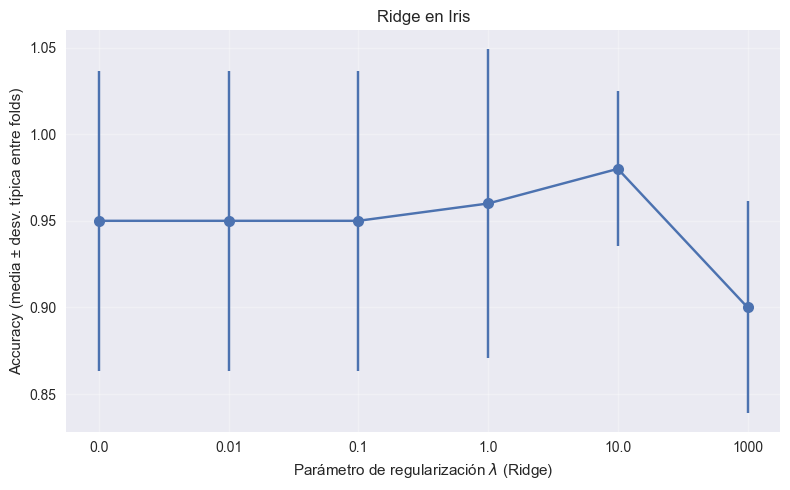

In [32]:
# Ejercicio 4: Ridge 

lambdas_ridge = [0.0, 0.01, 0.1, 1.0, 10.0, 1000]
k_ridge_exp = 5
random_state_exp = 42 # para que sea reproducible 

print("=== Ridge: efecto de λ===\n")

means = []
stds_fold = []

for lam in lambdas_ridge:
    try:
        res = cross_validate_model(
            x_ex1,
            y_ex1,
            RidgeLeastSquaresClassifier,
            k=k_ridge_exp,
            standardize=True,
            random_state=random_state_exp,
            verbose=True,
            lam=lam,
        )
    except np.linalg.LinAlgError as e:
        print(f"λ = {lam:g} -> LinAlgError al resolver el sistema: {e}")
        means.append(np.nan)
        stds_fold.append(np.nan)
        continue

    m = res["mean_accuracy"]
    v = res["var_accuracy"]
    s = np.sqrt(v) if v > 0 else 0.0
    means.append(m)
    stds_fold.append(s)
    print(f"λ = {lam:>5g}  |  accuracy media = {m:.4f}  |  var entre folds = {v:.6f}  |  desv. típica = {s:.4f}")
    print(f"           accuracies por fold: {np.round(res['accuracies'], 4)}")
    print()

xpos = np.arange(len(lambdas_ridge))
plt.figure(figsize=(8, 5))
plt.errorbar(xpos, means, yerr=stds_fold, fmt="-o", capsize=4, markersize=8)
plt.xticks(xpos, [str(l) for l in lambdas_ridge])
plt.xlabel(r"Parámetro de regularización $\lambda$ (Ridge)")
plt.ylabel("Accuracy (media ± desv. típica entre folds)")
plt.title("Ridge en Iris")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Interpretación de los resultados
1. $\lambda \in {0, 0.01, 0.1}$: Los resultados son idénticos
La media (0.95) y el vector por fold [0.8, 1, 1, 1, 0.95] son los mismos. Eso indica que, en este problema con $n=100$ y $d=4$, añadir una penalización muy pequeña casi no mueve la solución respecto a mínimos cuadrados. El sistema está bien condicionado y los pesos que minimizan el error cuadrático ya son parecidos a los de Ridge. Esos pesos no se están yendo lejos. Esto no significa que ridge no sirva, solo que hasta $\lambda=0.1$ el efecto numéricamente no es notable


2. $\lambda = 1$: sube un poco la media y cambia el fold 5
La media pasa a 0.96 porque el fold 5 pasa de 0.95 a 1.0 (los otros folds siguen igual, incluido el fold 1 en 0.8). La regularización moderada está penalizando lo suficiente como para acertar uno más en ese fold de prueba. La varianza entre folds sube muy poco (0.008 vs 0.0075), sigue habiendo un fold claramente peor (0.8).


3. $\lambda = 10$: mejor media y más estabilidad entre folds
La media sube a 0.98: el fold 1 mejora de 0.8 a 0.9 (cuatro folds siguen en 1.0).
La desviación típica entre folds baja (~0.045 frente a ~0.087) lo que quiere decir que las cinco accuracies están más parecidas entre sí.
Con más $\lambda$, los pesos se encogen y la frontera se suaviza. En un fold donde el entrenamiento era más “difícil” o ruidoso (el que daba 0.8), un modelo menos ajustado a especificidades  del train de ese fold generaliza mejor en test. Por eso aquí no vemos subajuste fuerte con $\lambda=10$: La colección de Iris es simple y 10 no es tan extremo como para anular la separación; además solo tenemos 5 medidas por $\lambda$, con mucha discretización (accuracy en test de ~20 puntos por fold). En este experimento se usó un k=5 para validación cruzada, por lo que cada fold tendrá aproximadamente 20 datos. La accuracy en ese fold es aciertos / 20, así que solo puede tomar valores saltando de 0.05 en 0.05, como vemos:

19/20 → 0.95
18/20 → 0.90
20/20 → 1.00
16/20 → 0.80

etc


Como no es una curva continua, un solo ejemplo mal clasificado en el test de 20 puntos mueve la accuracy 5 puntos porcentuales. Con tan pocos puntos por fold, pequeños cambios en el modelo pueden no cambiar el conteo de aciertos, o cambiarlo de golpe. Eso hace que las barras entre folds salten y que interpretar diferencias sea más ruidoso.

$\lambda=0$: equivale a mínimo cuadrado puro. Aquí da el mismo patrón que $\lambda$ pequeño porque el problema no exige que usemos Ridge para estabilidad numérica.
En teoría, $\lambda$ muy grande fuerza pesos casi nulos y puede bajar la accuracy; en los resultados, $\lambda=10$ mejora media y estabilidad porque reduce sobreajuste al subconjunto de entrenamiento de los folds "duros o difíciles”. Eso no contradice la teoría, ya que el subajuste severo aparecería con $\lambda$ aún mayores o en problemas donde la separación ya es difícil.
En cuanto a estabilidad, hay una menor dispersión entre folds con $\lambda=10$, lo que nos indica que el modelo es menos sensible a qué 80 puntos entren en cada partición.

Se agregó un lambda de 1000 paran verificar y estos son los resultados, donde vemos que el accuracy disminuye y la varianza aumenta. De nuevo, lo que pasa es que el modelo deja de separar bien las clases porque la frontera es casi trivial

Fold 1/5 - accuracy = 0.9000
Fold 2/5 - accuracy = 0.9500
Fold 3/5 - accuracy = 0.9000
Fold 4/5 - accuracy = 0.9500
Fold 5/5 - accuracy = 0.8000
λ =  1000  |  accuracy media = 0.9000  |  var entre folds = 0.003750  |  desv. típica = 0.0612
           accuracies por fold: [0.9  0.95 0.9  0.95 0.8 ]